# Đề tài: Phân tích hiệu quả kinh doanh và xây dựng mô hình dự báo doanh thu cho chuỗi siêu thị đa chi nhánh tại Myanmar

## Data Dictionary:
- Invoice ID – Unique identifier for each transaction/invoice.
- Branch – Branch code of the supermarket (e.g., A, B, C).
- City – City where the supermarket branch is located.
- Customer type – Type of customer (e.g., Member, Normal).
- Gender – Gender of the customer.
- Product line – Product category (e.g., Health and beauty, Electronic - accessories, Food and beverages).
- Unit price – Price of a single product unit.
- Quantity – Number of product units purchased.
- Tax 5% – 5% tax amount applied to the purchase.
- Total – Total price including tax.
- Date – Date of purchase.
- Time – Time of purchase.
- Payment – Payment method (e.g., Cash, Credit card, Ewallet).
- cogs – Cost of goods sold (before tax).
- gross margin percentage – Gross margin percentage for the transaction.
- gross income – Profit earned from the transaction (cogs × margin).
- Rating – Customer satisfaction rating (typically 1–10).

## Tiếng Việt:
- Invoice ID – Mã định danh duy nhất cho mỗi giao dịch/hóa đơn.
- Branch – Mã chi nhánh của siêu thị (ví dụ: A, B, C).
- City – Thành phố nơi chi nhánh siêu thị tọa lạc.
- Customer type – Loại khách hàng (ví dụ: Thành viên, Khách hàng thông thường).
- Gender – Giới tính của khách hàng.
- Product line – Danh mục sản phẩm (ví dụ: Sức khỏe và sắc đẹp, Điện tử - phụ kiện, Thực phẩm và đồ uống).
- Unit price – Giá của một đơn vị sản phẩm.
- Quantity – Số lượng đơn vị sản phẩm đã mua.
- Tax 5% – Thuế suất 5% áp dụng cho giao dịch mua.
- Total – Tổng giá bao gồm thuế.
- Date – Ngày mua hàng.
- Time – Giờ mua hàng.
- Payment – Phương thức thanh toán (ví dụ: Tiền mặt, Thẻ tín dụng, Ví điện tử).
- cogs – Giá vốn hàng bán (trước thuế).
- gross margin percentage – Tỷ lệ lợi nhuận gộp của giao dịch. 
- gross income – Lợi nhuận thu được từ giao dịch (giá vốn hàng bán × tỷ suất lợi nhuận).
- Rating – Mức độ hài lòng của khách hàng (thường từ 1–10).

# Import thư viện và Đọc dữ liệu

In [60]:
# Cài đặt thư viện xử
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Tiền xử lý dữ liệu
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

# Mô hình Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Đánh giá mô hình
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

In [61]:
path = './data/Supermarket_sales.csv'
alpha = 0.5

df = pd.read_csv(path)

In [62]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [63]:
df.tail()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
995,233-67-5758,C,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,13:46,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,B,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,17:16,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,A,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,13:22,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,A,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,15:33,Cash,65.82,4.761905,3.2910,4.1
999,849-09-3807,A,Yangon,Member,Female,Fashion accessories,88.34,7,30.9190,649.2990,2/18/2019,13:28,Cash,618.38,4.761905,30.9190,6.6


# Data Preparation / Data Preprocessing / EDA

## Data Understanding (Thấu hiểu dữ liệu)

In [64]:
df.shape

# Data có 1000 dòng và 17 cột

(1000, 17)

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [66]:
df.describe()

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,0.000000,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905,49.650000,10.00000


In [67]:
df.describe(include='object')	

,Invoice ID,Branch,City,Customer type,Gender,Product line,Date,Time,Payment
count,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,1000,3,3,2,2,6,89,506,3
top,750-67-8428,A,Yangon,Member,Female,Fashion accessories,2/7/2019,19:48,Ewallet
freq,1,340,340,501,501,178,20,7,345


In [68]:
df.nunique()

# Có 3 branch: A, B, C
# Ở 3 thành phố: Yangon, Mandalay, Naypyitaw
# 2 loại khách hàng: Member và Normal
# 6 Produt line: Fashion accessories, Food and beverages, Electronic accessories, Sports and travel, Home and lifestyle, Health and beauty
# 3 loại thanh toán: Cash, Credit card, Ewallet

Invoice ID                 1000
Branch                        3
City                          3
Customer type                 2
Gender                        2
Product line                  6
Unit price                  943
Quantity                     10
Tax 5%                      990
Total                       990
Date                         89
Time                        506
Payment                       3
cogs                        990
gross margin percentage       1
gross income                990
Rating                       61
dtype: int64

## Data Cleaning (Dọn dẹp dữ liệu)

In [69]:
df.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [70]:
df.duplicated().sum()

0

In [71]:
df.dtypes

# Date và Time đang ở dạng object, cần chuyển về datetime
# Branch, City, Customer type, Gender, Product line, và Payment đang ở dạng object, cần chuyển về category

Invoice ID                  object
Branch                      object
City                        object
Customer type               object
Gender                      object
Product line                object
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Total                      float64
Date                        object
Time                        object
Payment                     object
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

In [72]:
# 1. Chuyển đổi ngày tháng
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time']).dt.time # Hoặc giữ nguyên datetime tùy mục đích

# 2. Chuyển đổi các cột phân loại
category_cols = ['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Payment']
for col in category_cols:
    df[col] = df[col].astype('category')
    
df.dtypes

C:\Users\ngong\AppData\Local\Temp\ipykernel_1976\2477708677.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time']).dt.time # Hoặc giữ nguyên datetime tùy mục đích


Invoice ID                         object
Branch                           category
City                             category
Customer type                    category
Gender                           category
Product line                     category
Unit price                        float64
Quantity                            int64
Tax 5%                            float64
Total                             float64
Date                       datetime64[ns]
Time                               object
Payment                          category
cogs                              float64
gross margin percentage           float64
gross income                      float64
Rating                            float64
dtype: object

In [73]:
quantCols = ['Unit price', 'Tax 5%', 'Quantity', 'Total']

# Kiểm tra xem có giá trị âm không
negCounts = (df[quantCols] < 0).sum()
negCounts

#không có giá trị âm ở các cột số lượng

Unit price    0
Tax 5%        0
Quantity      0
Total         0
dtype: int64

## Univariate Analysis (Phân tích đơn biến)

In [74]:
df.head(2)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08:00,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00,Cash,76.40,4.761905,3.8200,9.6


C:\Users\ngong\AppData\Local\Temp\ipykernel_1976\4056038795.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Branch', data=df, palette='Set1')
C:\Users\ngong\AppData\Local\Temp\ipykernel_1976\4056038795.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(custom_labels)


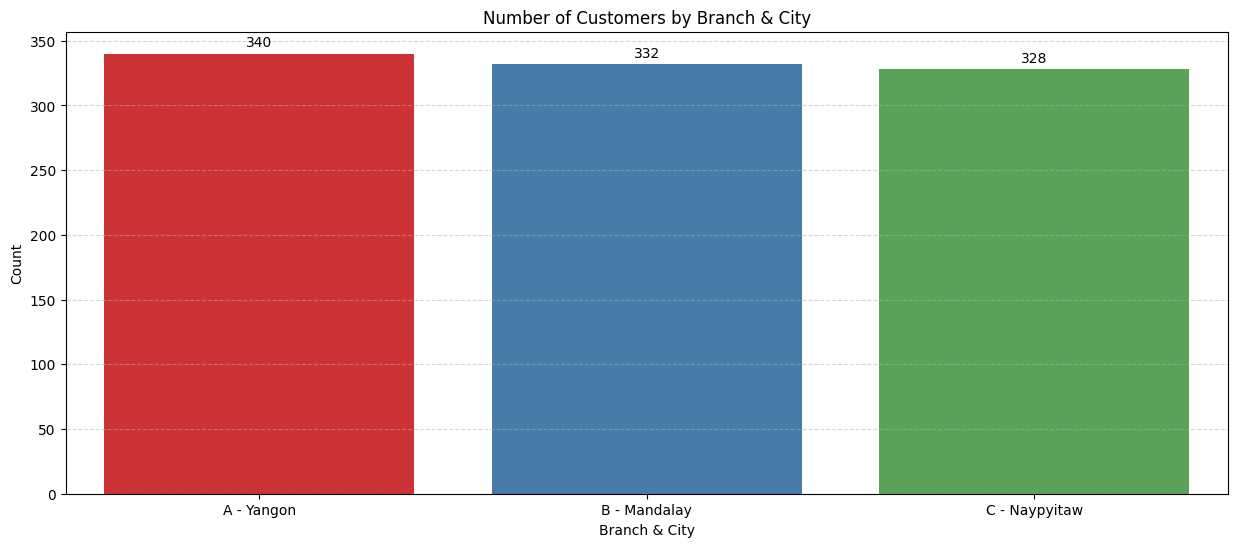

In [75]:
# Branch và City có mối quan hệ 1-1

plt.figure(figsize=(15, 6))
ax = sns.countplot(x='Branch', data=df, palette='Set1')
custom_labels = ['A - Yangon', 'B - Mandalay', 'C - Naypyitaw']
ax.set_xticklabels(custom_labels)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.title('Number of Customers by Branch & City')
plt.xlabel('Branch & City')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=alpha)

plt.show()

**Nhận xét:** Biểu đồ cho thấy sự cân bằng về số lượng khách hàng tại 3 thành phố lớn.

**Số liệu:**
- **Yangon (A)** dẫn đầu với 340 lượt khách.
- **Naypyitaw (C) và Mandalay (B)** bám sát với lần lượt 328 và 332 lượt khách.

C:\Users\ngong\AppData\Local\Temp\ipykernel_1976\1603368551.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(data=df, x='Customer type', palette='Set2')


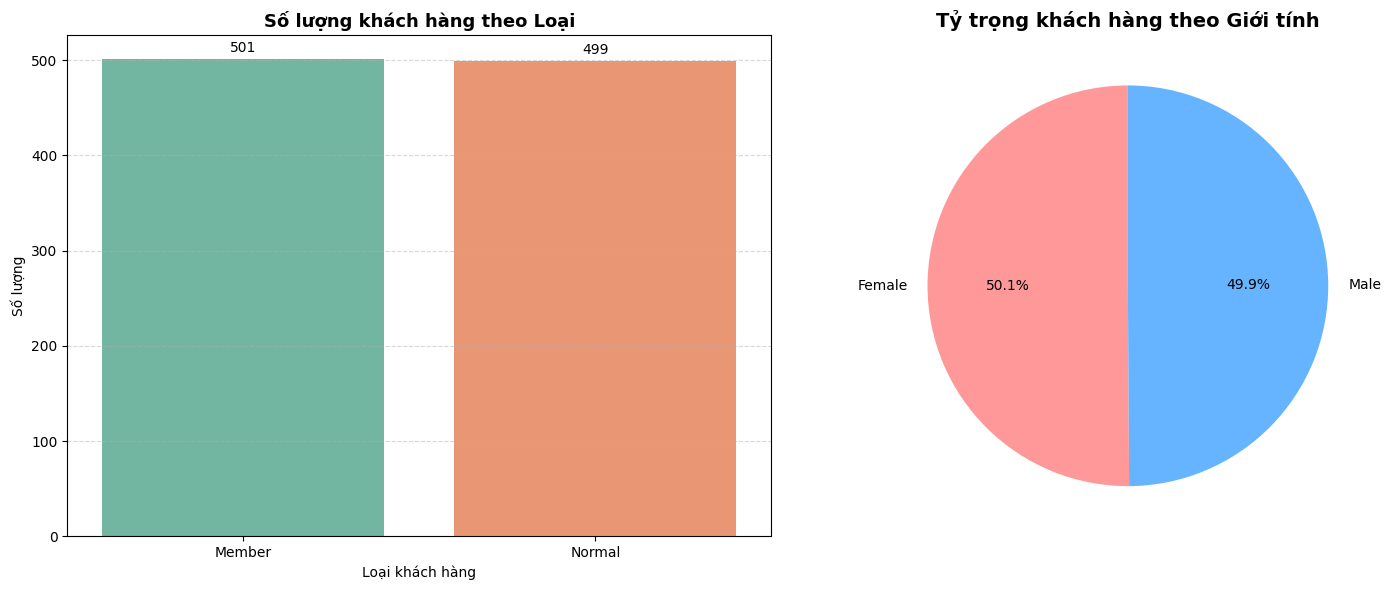

In [76]:
# Customer type
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
ax1 = sns.countplot(data=df, x='Customer type', palette='Set2')
for container in ax1.containers:
    ax1.bar_label(container, fmt='%d', padding=3)
plt.title('Số lượng khách hàng theo Loại', fontsize=13, fontweight='bold')
plt.xlabel('Loại khách hàng')
plt.ylabel('Số lượng')
plt.grid(axis='y', linestyle='--', alpha=alpha)


# Gender
gender_counts = df['Gender'].value_counts()
plt.subplot(1, 2, 2)
plt.pie(gender_counts, 
        labels = gender_counts.index, 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=['#ff9999','#66b3ff'],
        )

plt.title('Tỷ trọng khách hàng theo Giới tính', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**Nhận xét:** Cả hai biểu đồ đều cho thấy một sự cân bằng tuyệt đối trong tập dữ liệu. Doanh nghiệp đang phục vụ một lượng khách hàng cực kỳ đa dạng và không bị lệch về bất kỳ nhóm đối tượng cụ thể nào.

<!-- Biểu đồ 1: Phân bổ theo Loại khách hàng (Customer type)

Số liệu: Nhóm khách hàng Member (Thành viên) và Normal (Khách lẻ) có số lượng gần như bằng nhau, đạt mức xấp xỉ 500 khách hàng cho mỗi nhóm.

Ý nghĩa: Tỷ lệ chuyển đổi khách hàng vãng lai sang khách hàng thân thiết đang ở mức 50%. Đây là một chỉ số khá tốt, cho thấy các chính sách thành viên có sức hút nhưng vẫn còn dư địa 50% khách hàng lẻ để tiếp tục khai thác.

Biểu đồ 2: Phân bổ theo Giới tính (Gender)

Số liệu: Tương tự, số lượng khách hàng Nam (Male) và Nữ (Female) cũng dao động quanh mức 500 người.

Ý nghĩa: Sản phẩm hoặc dịch vụ của doanh nghiệp mang tính đại chúng cao (Unisex). Không có sự phân biệt về nhu cầu giữa nam và nữ trong việc tiêu dùng tại các chi nhánh. -->

             Product line  Count
0     Fashion accessories    178
1      Food and beverages    174
2  Electronic accessories    170
3       Sports and travel    166
4      Home and lifestyle    160
5       Health and beauty    152


C:\Users\ngong\AppData\Local\Temp\ipykernel_1976\3965847674.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


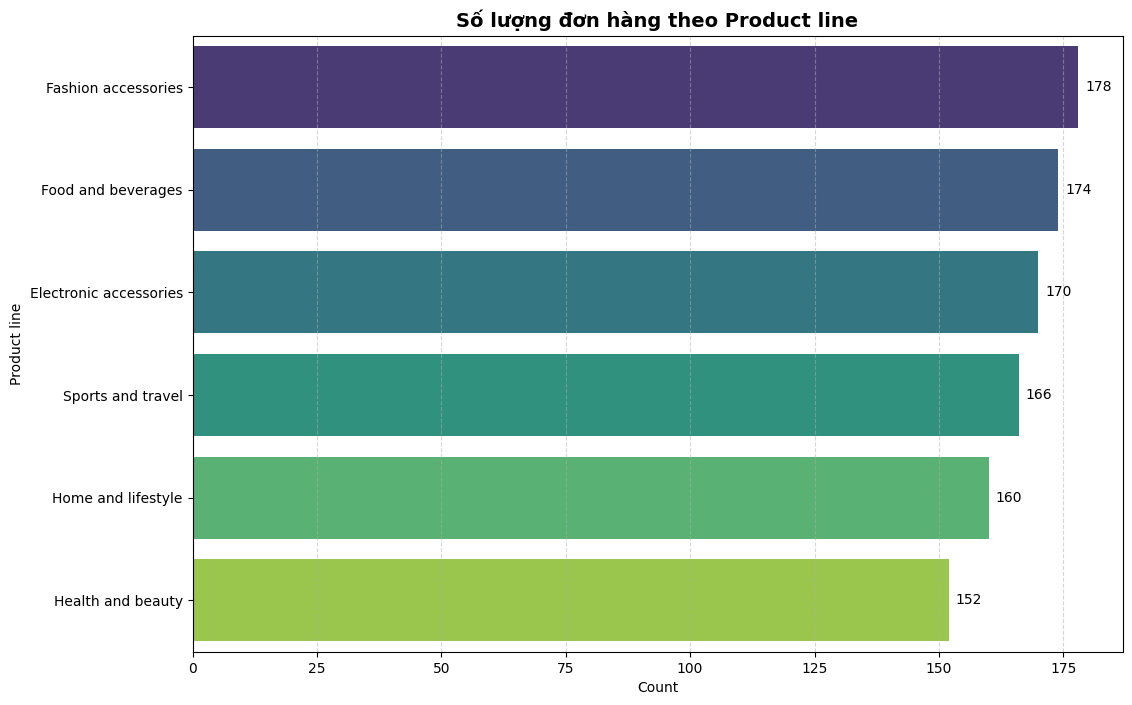

In [ ]:
# Product line
product_counts = df['Product line'].value_counts().reset_index()
product_counts.columns = ['Product line', 'Count']
print(product_counts)

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    x='Count', 
    y='Product line',
    hue = 'Product line',
    data=product_counts, 
    palette='viridis',
    order=product_counts['Product line']
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=5)

plt.grid(axis='x', linestyle='--', alpha=alpha)

plt.title('Số lượng đơn hàng theo Product line', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Product line')

plt.show()

**Nhận xét:** Biểu đồ thể hiện số lượng đơn hàng của 6 dòng sản phẩm chính tại siêu thị. Nhìn chung, sự chênh lệch giữa dòng sản phẩm bán chạy nhất và bán chậm nhất là không quá lớn (khoảng 10-20 đơn hàng), cho thấy một danh mục sản phẩm có sức mua rất ổn định và đồng đều.

**Phân tích chi tiết:**
- Fashion accessories (Phụ kiện thời trang): Đang chiếm ưu thế với số lượng đơn hàng cao nhất. Điều này cho thấy khách hàng có xu hướng mua sắm các mặt hàng nhỏ lẻ, mang tính thẩm mỹ cao khi ghé thăm siêu thị.
- Food and beverages (Thực phẩm & Đồ uống): Xếp ngay sau đó, khẳng định đây là nhóm nhu yếu phẩm đóng vai trò "giữ chân" khách hàng thường xuyên.
- Health and beauty (Sức khỏe & Làm đẹp): Dù đứng cuối danh sách, nhưng con số này vẫn đạt mức khá cao (trên 150 đơn), chứng tỏ tiềm năng khai thác của nhóm ngành này vẫn còn rất lớn.